# Configuration

In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using winners_curse from: c:\Users\xusik\Desktop\research\winners-curse\src\winners_curse


In [2]:
import os 
import pickle 
import json

from typing import Iterable, Union
from joblib import Parallel, delayed

In [3]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [4]:
from scipy.stats import ttest_1samp, norm, wilcoxon
from scipy.integrate import quad 

In [5]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [6]:
from winners_curse.dgp import ABTest, DataGenerationProcess
import winners_curse.ab_test as ab_test
from winners_curse.variables import *
from winners_curse.utils import *
from winners_curse.analysis import *
from winners_curse.bootstrap import get_bootstrap_distribution

# Simulation Breakdown

## DGP

In [7]:
# continuous specification
dgp_params = {
    'base_effects': [PointMass(1), PointMass(1.05)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

dgp = ABTest(**dgp_params)

In [8]:
samples = dgp.sample(sample_size=[1000, 4000], seed=0)

## Estimation

In [9]:
emp_te_arr, emp_var_arr = ab_test.estimate_treatment_effects(samples, response_type=dgp.response_type)

## Selection

In [36]:
selection = ab_test.select_higher_effect(treatment_effects=emp_te_arr, treatment_effect_vars=emp_var_arr)

## Evaluation

In [37]:
val_est = ab_test.obj_func(selection=selection, treatment_effects=emp_te_arr, response_type=dgp.response_type,)
val_true = ab_test.obj_func(selection=selection, treatment_effects=dgp.treatment_effects, response_type=dgp.response_type,)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,1.042907
True Policy Value,1.050000
Winner's Curse,-0.007093


In [38]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

## Compute Winner's Curse

In [57]:
optimization_params = {
    'optimizer': ab_test.select_higher_effect,
    'params': {}, 
    'display_name': 'Rank and Select'
}

dgp_params = {
    'base_effects': [PointMass(1), PointMass(1.01)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}


data_params = {'sample_size': [1000, 4000]}

experiment_params = {'n_repeats': 500}

estimators_dict = {}

result_records = ab_test.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0024955272674560547s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.01818704605102539s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 132 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 170 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.0158236026763916s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 308 tasks      | elapsed:    0.0s
[Parallel(n_jo

In [43]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
display_name = optimization_params['display_name']

# unpack results
wc_arr = np.array([result[f'wc'] for result in result_records])
val_true_arr = np.array([result[f'val_true'] for result in result_records])
val_est_arr = np.array([result[f'val_est'] for result in result_records])

wc_avg = wc_arr.mean()
wc_std = wc_arr.std()

val_true_avg = val_true_arr.mean()
val_true_std = val_true_arr.std()
val_est_avg = val_est_arr.mean()
val_est_std = val_est_arr.std()

print(f'\nSelection with {display_name}:')
print(f'  - Average True Value: {val_true_avg:.6f} ({val_true_std:.6f})')
print(f'  - Average Estimated Value: {val_est_avg:.6f} ({val_est_std:.6f})')
print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.4%} ({wc_std:.4%})')


Selection with Rank and Select:
  - Average True Value: 1.006120 (0.004873)
  - Average Estimated Value: 1.020157 (0.018228)
  - Average Winner's Curse (%): 140.3696% (2.0446%)


## Estimating Winner's Curse

In [60]:
dgp = ABTest(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=3)

In [61]:
# Define wrappers for generic bootstrap
def estimator_func(data, **kwargs):
    return ab_test.estimate_treatment_effects(
        data, response_type=dgp.response_type, 
    )

def optimizer_func(estimates, **kwargs):
    te_arr, var_arr = estimates
    return ab_test._apply_optimizer(optimization_params, te_arr, var_arr)

def evaluator_func(selection, estimates, **kwargs):
    te_arr, _ = estimates
    return ab_test.obj_func(selection, te_arr, response_type=dgp.response_type)

### Standard Bootstrap

In [62]:
def bootstrap_sampler_func(data, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Handle different sample sizes per treatment
    return [np.random.choice(sample, size=len(sample), replace=True) for sample in data]

stand_boot_wc_dstn = get_bootstrap_distribution(
    samples, 
    estimator_func, 
    optimizer_func, 
    evaluator_func, 
    bootstrap_sampler_func, 
    n_bootstraps=5000, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4038 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.4s finished


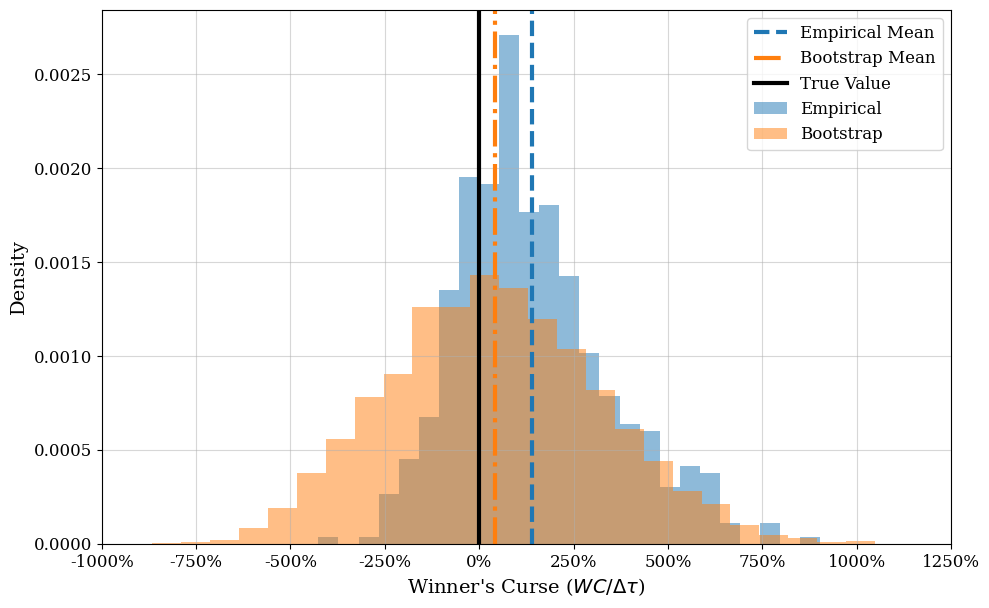

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params['display_name']

delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
wc_dstn = np.array([result[f'wc'] for result in result_records]) / delta_tau * 100
wc_boot_dstn = stand_boot_wc_dstn / delta_tau * 100

sns.histplot(wc_dstn, bins=25, color='C0', alpha=0.5, edgecolor=None, stat='density', label='Empirical', ax=ax)
ax.axvline(x=wc_dstn.mean(), color='C0', linestyle='--', linewidth=3, label='Empirical Mean')

sns.histplot(wc_boot_dstn, bins=25, color='C1', alpha=0.5, edgecolor=None, stat='density', label='Bootstrap', ax=ax)
ax.axvline(x=wc_boot_dstn.mean(), color='C1', linestyle='dashdot', linewidth=3, label='Bootstrap Mean')

ax.axvline(x=0, color='black', linestyle='-', linewidth=3, label='True Value')

ax.set_xlabel(r"Winner's Curse ($WC/\Delta\tau$)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_xticks(ax.get_xticks(), [f'{x:.0f}%' for x in ax.get_xticks()])
# ax.set_title(f'{display_name} Selection')
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### m-out-of-n Bootstrap

In [64]:
def bootstrap_sampler_func(data, seed=None):
        if seed is not None:
            np.random.seed(seed)
        # Handle different sample sizes per treatment - use m-out-of-n for each
        return [np.random.choice(sample, size=int(len(sample) ** 0.95), replace=True) for sample in data]

mn_boot_wc_dstn = get_bootstrap_distribution(
    samples, 
    estimator_func, 
    optimizer_func, 
    evaluator_func, 
    bootstrap_sampler_func, 
    n_bootstraps=1000, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


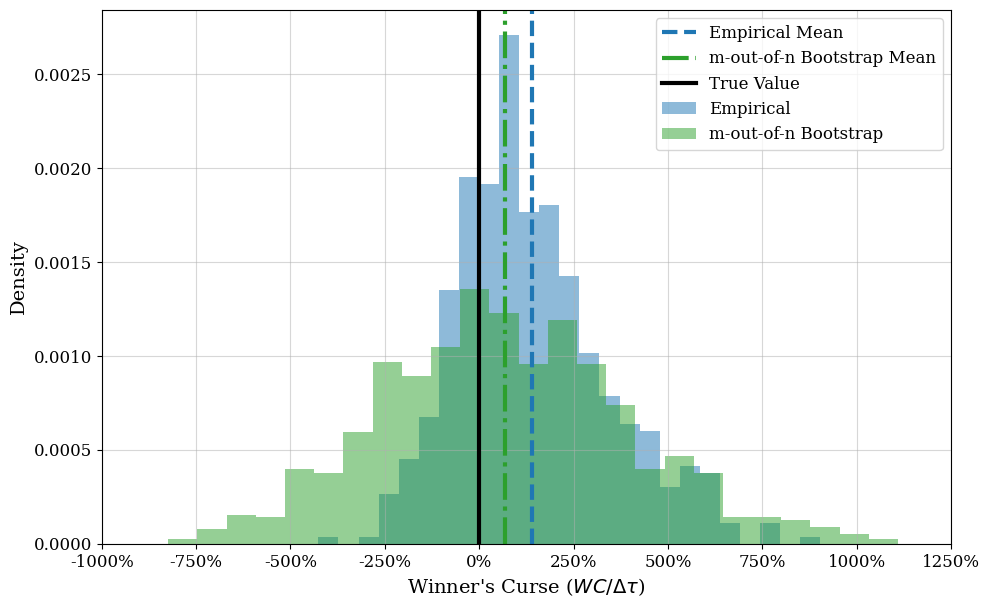

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params['display_name']

delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
wc_dstn = np.array([result[f'wc'] for result in result_records]) / delta_tau * 100
wc_boot_dstn = mn_boot_wc_dstn / delta_tau * 100

sns.histplot(wc_dstn, bins=25, color='C0', alpha=0.5, edgecolor=None, stat='density', label='Empirical', ax=ax)
ax.axvline(x=wc_dstn.mean(), color='C0', linestyle='--', linewidth=3, label='Empirical Mean')

sns.histplot(wc_boot_dstn, bins=25, color='C2', alpha=0.5, edgecolor=None, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.axvline(x=wc_boot_dstn.mean(), color='C2', linestyle='dashdot', linewidth=3, label='m-out-of-n Bootstrap Mean')

ax.axvline(x=0, color='black', linestyle='-', linewidth=3, label='True Value')

ax.set_xlabel(r"Winner's Curse ($WC/\Delta\tau$)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_xticks(ax.get_xticks(), [f'{x:.0f}%' for x in ax.get_xticks()])
# ax.set_title(f'{display_name} Selection')
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

### Numerical Bootstrap

In [66]:
def bootstrap_sampler_func(data, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Handle different sample sizes per treatment
    return [np.random.choice(sample, size=len(sample), replace=True) for sample in data]

def wc_func(boot_sel, boot_est, emp_est, evaluator_func):
    boot_te_arr, _ = boot_est
    emp_te_arr, _ = emp_est
    # Use average sample size for numerical bootstrap power calculation
    sample_sizes = np.array([sample.shape[0] for sample in samples])
    epsilons = sample_sizes ** (-0.45)
    
    norm_error = np.sqrt(sample_sizes) * (boot_te_arr - emp_te_arr)
    perturbed_te_arr = emp_te_arr + epsilons * norm_error
    
    emp_val_est = evaluator_func(boot_sel, emp_est)
    
    # For perturbed value, we need to pass perturbed estimates to evaluator
    # But evaluator_func extracts te_arr from estimates tuple
    # So we wrap perturbed_te_arr in a tuple
    perturbed_est = (perturbed_te_arr, None)
    perturbed_val_est = evaluator_func(boot_sel, perturbed_est)
    
    return perturbed_val_est - emp_val_est

num_boot_wc_dstn = get_bootstrap_distribution(
    samples, 
    estimator_func, 
    optimizer_func, 
    evaluator_func, 
    bootstrap_sampler_func, 
    wc_func, 
    n_bootstraps=1000, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.2s finished


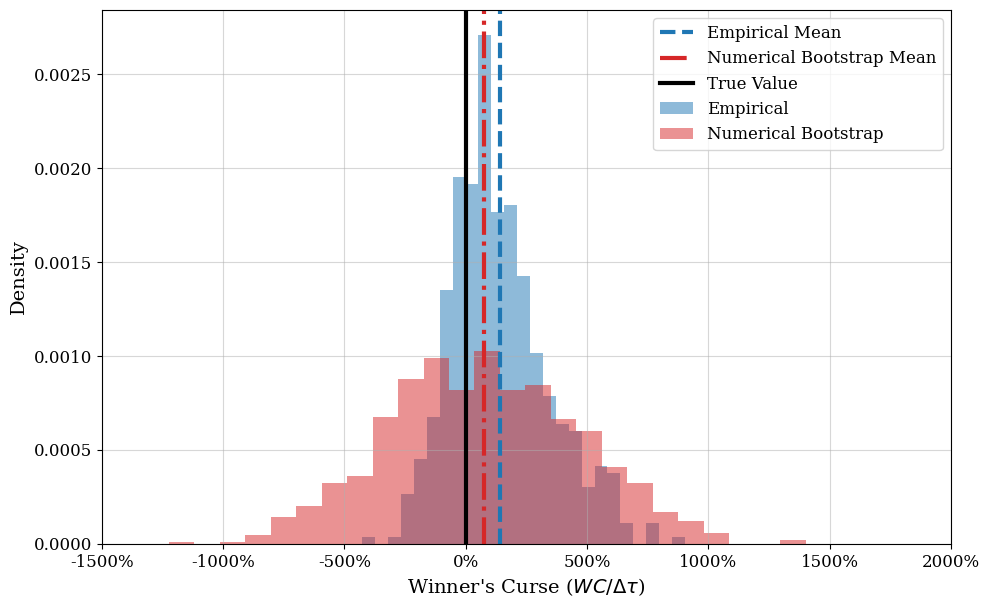

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params['display_name']

delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
wc_dstn = np.array([result[f'wc'] for result in result_records]) / delta_tau * 100
wc_boot_dstn = num_boot_wc_dstn / delta_tau * 100

sns.histplot(wc_dstn, bins=25, color='C0', alpha=0.5, edgecolor=None, stat='density', label='Empirical', ax=ax)
ax.axvline(x=wc_dstn.mean(), color='C0', linestyle='--', linewidth=3, label='Empirical Mean')

sns.histplot(wc_boot_dstn, bins=25, color='C3', alpha=0.5, edgecolor=None, stat='density', label='Numerical Bootstrap', ax=ax)
ax.axvline(x=wc_boot_dstn.mean(), color='C3', linestyle='dashdot', linewidth=3, label='Numerical Bootstrap Mean')

ax.axvline(x=0, color='black', linestyle='-', linewidth=3, label='True Value')

ax.set_xlabel(r"Winner's Curse ($WC/\Delta\tau$)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_xticks(ax.get_xticks(), [f'{x:.0f}%' for x in ax.get_xticks()])
# ax.set_title(f'{display_name} Selection')
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## Bias Correction

In [10]:
optimization_params = {
    'optimizer': ab_test.select_higher_effect,
    'params': {}, 
    'display_name': 'Rank and Select'
}

dgp_params = {
    'base_effects': [PointMass(1), PointMass(1.01)],
    'response_type': 'continuous', 
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': [1000, 4000]}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': ab_test.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': ab_test.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': ab_test.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'sample_splitting': {
        'estimator': ab_test.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'hybrid_si': {
        'estimator': ab_test.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [11]:
result_records = ab_test.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = ab_test.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 117 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 178 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 201 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 249 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 274 tasks      | elapsed:  

In [12]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# No Correction
nc_wc_avg = wc_measures_dict['nc_wc_arr'].mean() / delta_tau * 100
nc_wc_std = wc_measures_dict['nc_wc_arr'].std() / delta_tau * 100
print(f"No Correction: {nc_wc_avg:.2f}% ({nc_wc_std:.2f}%)")


for estimator_key in estimators_dict.keys():
    wc_avg = wc_measures_dict[f'{estimator_key}_wc_arr'].mean() / delta_tau * 100
    wc_std = wc_measures_dict[f'{estimator_key}_wc_arr'].std() / delta_tau * 100
    print(f"{estimators_dict[estimator_key]['display_name']}: {wc_avg:.2f}% ({wc_std:.2f}%)")


No Correction: 140.37% (204.46%)
Standard Bootstrap: 45.14% (218.91%)
m-out-of-n Bootstrap: 15.38% (219.32%)
Numerical Bootstrap: 3.92% (227.22%)
Sample Splitting: 0.99% (327.74%)
Hybrid SI: -31.70% (344.22%)


# Comparative Statics

## SNR

In [7]:
result_dir = '../results/ab_test_snr_20251122_122117'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    snr_results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    snr_config: dict = json.load(f)

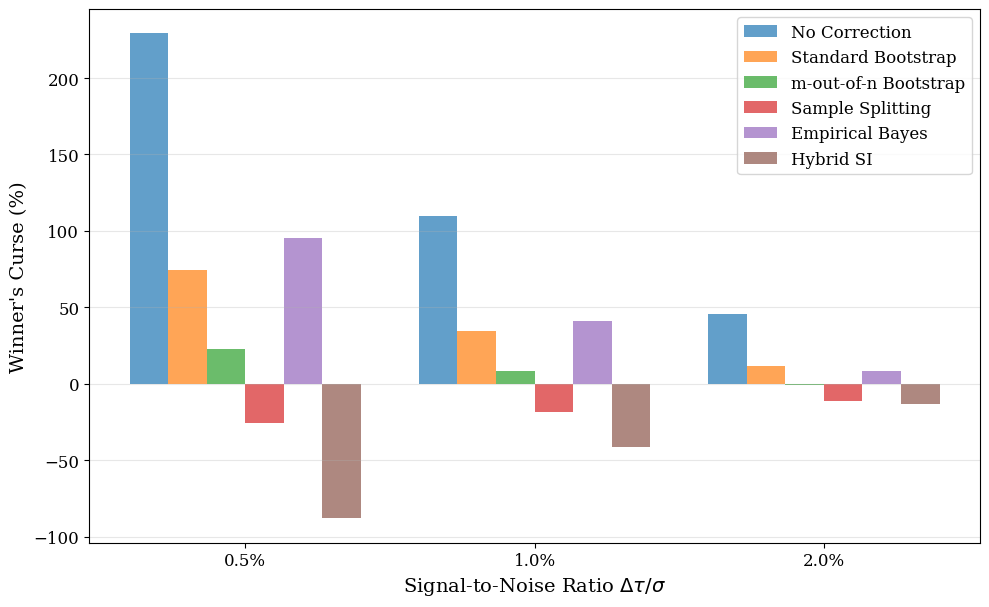

$\Delta\tau$                          0.5%        1.0%        2.0%
Estimator            Statistic                                    
No Correction        mean       229.320305  109.628445   45.715523
                     median     202.374180  100.444413   41.030837
                     std        335.472955  170.685436   90.174491
Standard Bootstrap   mean        74.620978   34.729636   11.897672
                     median      39.430336   19.601187    4.154170
                     std        378.505443  191.371736   99.704493
m-out-of-n Bootstrap mean        22.736035    8.345278   -1.139868
                     median     -24.078523  -11.171225   -8.362703
                     std        380.685077  192.743467  100.702759
Sample Splitting     mean       -25.651936  -18.747318  -11.434770
                     median     -35.200526  -26.878949   -7.842647
                     std        581.715389  293.510987  154.116037
Empirical Bayes      mean        95.054303   40.962604    8.381464
                     median      84.924716   33.387271    2.158523
                     std        316.470849  162.858211   87.572361
Hybrid SI            mean       -88.156741  -41.686870  -12.962797
                     median     -21.080091  -10.266885   -1.328067
                     std        582.978679  293.642027  140.736199

In [8]:
plot_snr_wc_comparison(snr_results, snr_config)
stats_df = compute_snr_sum_stats(
    snr_results, snr_config, ['mean', 'median', 'std']
)
stats_df

In [12]:
latex_table = generate_snr_sum_stats_latex_table(
    snr_results, snr_config, 
    stats='mean', decimals=2
)
print(latex_table)

\begin{tabular}{cccc}
\toprule
$\Delta\tau/\sigma$ & 0.5% & 1.0% & 2.0% \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}229.32\%\\ (335.47\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}109.63\%\\ (170.69\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}45.72\%\\ (90.17\%)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}74.62\%\\ (378.51\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}34.73\%\\ (191.37\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}11.90\%\\ (99.70\%)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}22.74\%\\ (380.69\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}8.35\%\\ (192.74\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}-1.14\%\\ (100.70\%)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}-25.65\%\\ (581.72\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}-18.75\%\\ (293.51\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}-11.43\%\\ (154.12\%)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}95.05\%\\ (316.47\%)\end{tabul

In [13]:
print('50/50 Split Sample Splitting')
for tau_tup, value in snr_results.items():
    delta_tau = tau_tup[1] - tau_tup[0]

    agree_pct_avg = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).mean()
    agree_pct_std = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).std()
    
    clairvoyant_val = 1 + delta_tau
    focal_val_avg = np.mean(value['rank_and_select_nc_val_true_arr'])
    focal_val_std = np.std(value['rank_and_select_nc_val_true_arr'])
    ss_val_avg = np.mean(value['rank_and_select_sample_splitting_val_true_arr'])
    ss_val_std = np.std(value['rank_and_select_sample_splitting_val_true_arr'])
    random_val = 1 + delta_tau / 2

    val_diff = focal_val_avg - ss_val_avg
    val_diff_std = (focal_val_std ** 2 + ss_val_std ** 2) ** 0.5

    print(f"Delta Tau: {delta_tau:.3f}:")
    print(f"  Pct. of Same Decision: {agree_pct_avg:.2%} ({agree_pct_std:.2%})")
    print(f"  Clairvoyant Policy Value: {clairvoyant_val:.6f}")
    print(f"  Focal Policy Value: {focal_val_avg:.6f} ({focal_val_std:.6f})")
    print(f"  Sample Splitting Value: {ss_val_avg:.6f} ({ss_val_std:.6f})")
    print(f"  Random Guessing Value: {random_val:.6f}")
    print(f"  Val Diff: {val_diff:.6f} ({val_diff_std:.6f})")
    print(f"  Val Diff / Delta Tau: {val_diff / delta_tau:.4%} ({val_diff_std / delta_tau:.4%})")

50/50 Split Sample Splitting
Delta Tau: 0.005:
  Pct. of Same Decision: 72.60% (44.60%)
  Clairvoyant Policy Value: 1.005000
  Focal Policy Value: 1.002910 (0.002466)
  Sample Splitting Value: 1.002720 (0.002490)
  Random Guessing Value: 1.002500
  Val Diff: 0.000190 (0.003505)
  Val Diff / Delta Tau: 3.8000% (70.0956%)
Delta Tau: 0.010:
  Pct. of Same Decision: 72.40% (44.70%)
  Clairvoyant Policy Value: 1.010000
  Focal Policy Value: 1.006440 (0.004788)
  Sample Splitting Value: 1.005920 (0.004915)
  Random Guessing Value: 1.005000
  Val Diff: 0.000520 (0.006861)
  Val Diff / Delta Tau: 5.2000% (68.6149%)
Delta Tau: 0.020:
  Pct. of Same Decision: 78.20% (41.29%)
  Clairvoyant Policy Value: 1.020000
  Focal Policy Value: 1.015400 (0.008417)
  Sample Splitting Value: 1.013680 (0.009298)
  Random Guessing Value: 1.010000
  Val Diff: 0.001720 (0.012542)
  Val Diff / Delta Tau: 8.6000% (62.7092%)


## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': ab_test.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.01)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 5000}

estimators_dict = {
    # 'sample_splitting': {
    #     'estimator': rct.sample_splitting_estimate,
    #     'params': {'estimation_split': 0.5},
    #     'display_name': 'Sample Splitting'
    # }, 
    'standard_bootstrap': {
        'estimator': ab_test.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    # 'm_out_of_n_bootstrap': {
    #     'estimator': rct.bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
    #     'display_name': 'm-out-of-n Bootstrap', 
    # },
    # 'numerical_bootstrap': {
    #     'estimator': rct.bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
    #     'display_name': 'Numerical Bootstrap', 
    # }, 
    # 'plugin_correction': {
    #     'estimator': rct.plugin_correction_estimate, 
    #     'params': {}, 
    #     'display_name': 'Plugin Correction', 
    # }, 
    # 'plugin_correction_with_true': {
    #     'estimator': rct.plugin_correction_estimate, 
    #     'params': {'delta_tau': dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean, 'sigma': dgp_params['noise_vars'][0].std}, 
    #     'display_name': 'Plugin Correction (True)', 
    # }, 
    # 'eb_normal': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Normal)'
    # }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    # 'conditional_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Conditional SI'
    # }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

# sample_size_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000, 30000, 40000, 50000]
sample_size_list = [100, 250, 500, 1000, 2500, 5000, 7500, 10000, 25000, 50000, 75000, 100000]

In [ ]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = ab_test.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = ab_test.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )


Sample Size = 100
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 620 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 1620 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done 3020 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 4820 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   21.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 250
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 620 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 1620 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 3020 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 4820 tasks      | elapsed:   20.6s
[Parallel(n_jobs=-1)]: Done 4981 out of 5000 | elapsed:   21.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   21.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 500
Running 5000 experiments...


...

[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   31.2s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   55.9s
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  5.9min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  5.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 75000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   51.6s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  6.2min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  7.9min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed:  9.7min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  9.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Sample Size = 100000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   56.2s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1230 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 2430 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed:  9.2min
[Parallel(n_jobs=-1)]: Done 4980 tasks      | elapsed: 11.3min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 11.4min finished


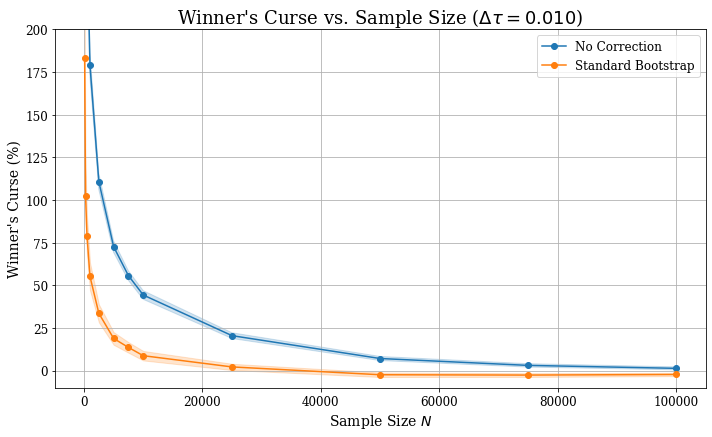

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
sample_size_list = list(sample_size_result_dict.keys())

# no correction
wc_avg_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'] for sample_size in sample_size_list]) / delta_tau * 100
wc_se_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_nc_wc_se'] for sample_size in sample_size_list]) / delta_tau * 100

ax.plot(sample_size_list, wc_avg_arr, color='C0', label='No Correction', marker='o')
ax.fill_between(
    sample_size_list, 
    wc_avg_arr - 1.96 * wc_se_arr, 
    wc_avg_arr + 1.96 * wc_se_arr, color='C0', alpha=0.2
)

# standard bootstrap
wc_boot_avg_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_standard_bootstrap_wc_avg'] for sample_size in sample_size_list]) / delta_tau * 100
wc_boot_se_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_standard_bootstrap_wc_se'] for sample_size in sample_size_list]) / delta_tau * 100

ax.plot(sample_size_list, wc_boot_avg_arr, color='C1', label='Standard Bootstrap', marker='o')
ax.fill_between(
    sample_size_list, 
    wc_boot_avg_arr - 1.96 * wc_boot_se_arr, 
    wc_boot_avg_arr + 1.96 * wc_boot_se_arr, color='C1', alpha=0.2
)

ax.set_ylim([-10, 200])

ax.set_title(r"Winner's Curse vs. Sample Size ($\Delta\tau = {:.3f}$)".format(delta_tau), fontsize=title_size)
ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.savefig(f'figures/rct_sample_size_{delta_tau:.3f}.svg')
plt.show()

In [39]:
# with open('results/ab_test_sample_size.pkl', 'wb') as f:
#     pickle.dump(sample_size_result_dict, f)

# with open('results/ab_test_sample_size.pkl', 'rb') as f:
#     sample_size_result_dict = pickle.load(f)

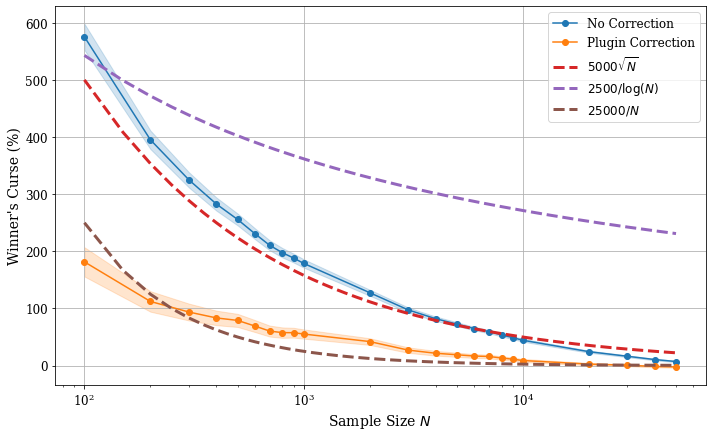

$N=100$  $N=200$  $N=300$  $N=400$  $N=500$  \
No Correction            Mean     575.40   395.20   324.94   282.73   255.73   
                         Median   574.24   379.78   312.29   269.63   243.37   
                         S.E.      11.75     8.27     6.81     5.87     5.29   
Plugin Correction        Mean     181.57   112.30    93.70    83.44    79.09   
                         Median   147.31    85.38    67.44    55.59    54.04   
                         S.E.      13.06     9.14     7.53     6.48     5.84   
Plugin Correction (True) Mean      12.62    -1.75     1.64     3.44     6.55   
                         Median    11.46   -17.17   -11.01    -9.66    -5.81   
                         S.E.      11.75     8.27     6.81     5.87     5.29   

                                 $N=600$  $N=700$  $N=800$  $N=900$  $N=1000$  \
No Correction            Mean     230.76   210.55   197.56   188.26    178.92   
                         Median   221.06   206.13   193.45   181.32    175.15   
                         S.E.       4.85     4.44     4.21     3.96      3.74   
Plugin Correction        Mean      69.19    60.44    57.71    57.61     55.28   
                         Median    51.26    50.14    41.72    44.30     44.69   
                         S.E.       5.35     4.90     4.65     4.37      4.13   
Plugin Correction (True) Mean       3.86     1.01     2.04     4.38      4.92   
                         Median    -5.84    -3.41    -2.07    -2.56      1.14   
                         S.E.       4.85     4.44     4.21     3.96      3.74   

                                 ...  $N=5000$  $N=6000$  $N=7000$  $N=8000$  \
No Correction            Mean    ...     72.65     64.79     59.60     53.65   
                         Median  ...     67.11     61.55     57.34     50.80   
                         S.E.    ...      1.72      1.55      1.47      1.40   
Plugin Correction        Mean    ...     18.99     16.73     15.98     13.27   
                         Median  ...     13.91     11.47     13.83     10.47   
                         S.E.    ...      1.88      1.70      1.62      1.53   
Plugin Correction (True) Mean    ...      2.23      2.10      2.99      2.01   
                         Median  ...     -3.30     -1.14      0.73     -0.84   
                         S.E.    ...      1.72      1.55      1.47      1.40   

                                 $N=9000$  $N=10000$  $N=20000$  $N=30000$  \
No Correction            Mean       48.96      44.38      24.43      16.33   
                         Median     48.64      42.28      22.03      15.87   
                         S.E.        1.35       1.29       0.94       0.79   
Plugin Correction        Mean       11.26       8.89       2.65       0.68   
                         Median     10.12       6.26       0.91       2.13   
                         S.E.        1.48       1.42       1.03       0.86   
Plugin Correction (True) Mean        1.47       0.44       0.23       0.95   
                         Median      1.15      -1.66      -2.17       0.48   
                         S.E.        1.35       1.29       0.94       0.79   

                                 $N=40000$  $N=50000$  
No Correction            Mean        10.57       7.17  
                         Median       8.97       6.11  
                         S.E.         0.70       0.62  
Plugin Correction        Mean        -1.54      -2.34  
                         Median      -1.50      -1.94  
                         S.E.         0.77       0.68  
Plugin Correction (True) Mean         0.19      -0.06  
                         Median      -1.41      -1.12  
                         S.E.         0.70       0.62  

[9 rows x 23 columns]

In [43]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


ax.plot(sample_size_list, wc_stats_df.loc['No Correction', 'Mean'], color='C0', label='No Correction', marker='o')
ax.fill_between(
    sample_size_list, 
    wc_stats_df.loc['No Correction', 'Mean'] - 1.96 * wc_stats_df.loc['No Correction', 'S.E.'], 
    wc_stats_df.loc['No Correction', 'Mean'] + 1.96 * wc_stats_df.loc['No Correction', 'S.E.'], color='C0', alpha=0.2
)

ax.plot(sample_size_list, wc_stats_df.loc['Plugin Correction', 'Mean'], color='C1', label='Plugin Correction', marker='o')
ax.fill_between(
    sample_size_list, 
    wc_stats_df.loc['Plugin Correction', 'Mean'] - 1.96 * wc_stats_df.loc['Plugin Correction', 'S.E.'], 
    wc_stats_df.loc['Plugin Correction', 'Mean'] + 1.96 * wc_stats_df.loc['Plugin Correction', 'S.E.'], color='C1', alpha=0.2
)

# ax.plot(sample_size_list, wc_stats_df.loc['Plugin Correction (True)', 'Mean'], color='C2', label='Plugin Correction (True)', marker='o')
# ax.fill_between(
#     sample_size_list, 
#     wc_stats_df.loc['Plugin Correction (True)', 'Mean'] - 1.96 * wc_stats_df.loc['Plugin Correction (True)', 'S.E.'], 
#     wc_stats_df.loc['Plugin Correction (True)', 'Mean'] + 1.96 * wc_stats_df.loc['Plugin Correction (True)', 'S.E.'], color='C2', alpha=0.2
# )

int_sample_sizes = np.linspace(sample_size_list[0], sample_size_list[-1], 1000)
ax.plot(int_sample_sizes, 5000 * int_sample_sizes ** -0.5, color='C3', linestyle='--', label='$5000 \sqrt{N}$', linewidth=3)
ax.plot(int_sample_sizes, 2500 / np.log(int_sample_sizes), color='C4', linestyle='--', label='$2500 /\log(N)$', linewidth=3)
ax.plot(int_sample_sizes, 25000 / int_sample_sizes, color='C5', linestyle='--', label='$25000 / N$', linewidth=3)

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(sample_size_list)
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

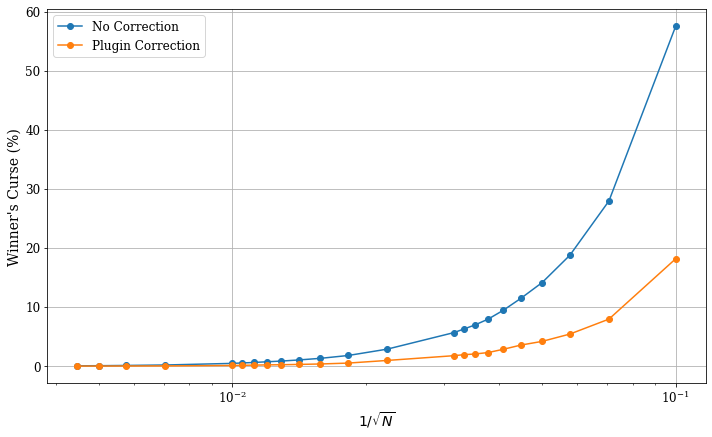

In [19]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


ax.plot(1 / np.sqrt(sample_size_list), wc_stats_df.loc['No Correction', 'Mean'] / np.sqrt(sample_size_list), color='C0', label='No Correction', marker='o')

ax.plot(1 / np.sqrt(sample_size_list), wc_stats_df.loc['Plugin Correction', 'Mean'] / np.sqrt(sample_size_list), color='C1', label='Plugin Correction', marker='o')

ax.set_xlabel(r'$1 / \sqrt{N}$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(sample_size_list)
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()

In [23]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccccccccc}
\toprule
 & $N=100$ & $N=200$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=7500$ & $N=10000$ & $N=25000$ & $N=50000$ & $N=75000$ & $N=100000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$151.18\%^{***}$\\ ($2.29\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$95.58\%^{***}$\\ ($1.69\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.90\%^{***}$\\ ($1.16\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$23.19\%^{***}$\\ ($0.86\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.34\%^{***}$\\ ($0.57\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.68\%^{*}$\\ ($0.41\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.41\%$\\ ($0.33\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.18\%$\\ ($0.28\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.05\%$\\ ($0.18\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.11\%$\\ ($0.13\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.14\%$\\ ($0.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.07\%$\\ ($0.09\%$)\

## $\Delta\tau / \sigma$

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': ab_test.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    # }, 
}

ratio_list = [0.01, 0.1, 0.5, 1, 2]
# ratio_list = [0.1, 1.0]

samp_vol_list = [1, 2, 3]


In [24]:
ratio_result_dict = {}

for ratio in ratio_list:
    for samp_vol in samp_vol_list:
        delta_tau = round(samp_vol * ratio, 2)
        print(f'\nRatio = {ratio}; Sampling Volatility = {samp_vol}; Delta tau= {delta_tau}')

        response_vol = np.sqrt(data_params['sample_size'] / 2) * samp_vol

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_vol), UnivariateGaussian(0, std=response_vol)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, samp_vol, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 0.01; Sampling Volatility = 1; Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 0.01; Sampling Volatility = 2; Delta tau= 0.02
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 2; Sampling Volatility = 2; Delta tau= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 2; Sampling Volatility = 3; Delta tau= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.7s finished


In [25]:
with open('results/ab_test_ratio.pkl', 'wb') as f:
    pickle.dump(ratio_result_dict, f)

with open('results/ab_test_ratio.pkl', 'rb') as f:
    ratio_result_dict = pickle.load(f)

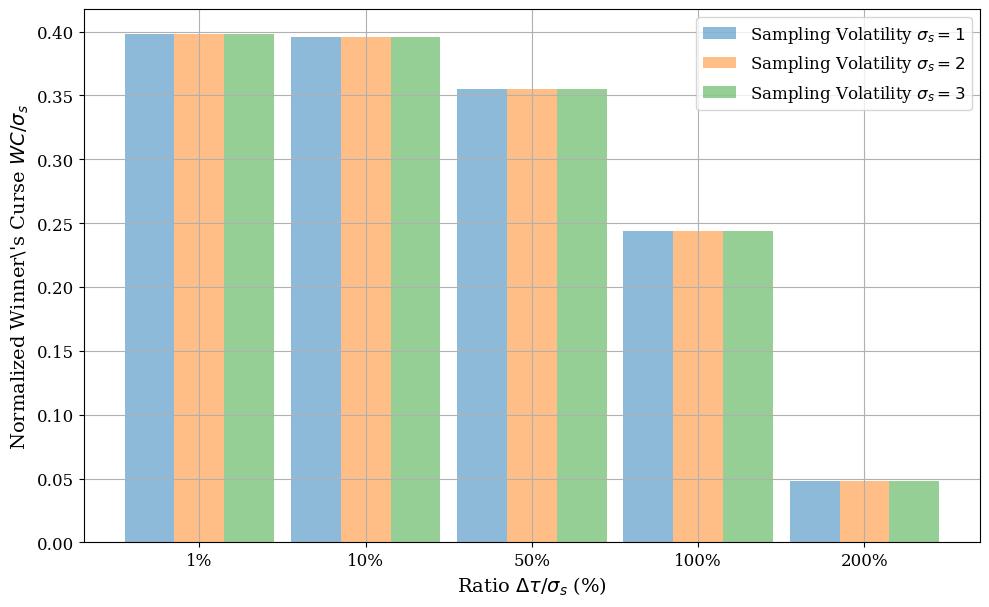

0.01  \
                                             $(\Delta\tau, \sigma_s) = (0.01, 1)$   
No Correction                         Mean                                 0.3978   
                                      Median                               0.3819   
                                      S.E.                                 0.0265   
Standard Bootstrap                    Mean                                 0.1198   
                                      Median                               0.0702   
                                      S.E.                                 0.0293   
m-out-of-n Bootstrap                  Mean                                 0.0457   
                                      Median                              -0.0065   
                                      S.E.                                 0.0294   
Numerical Bootstrap                   Mean                                 0.0161   
                                      Median                              -0.0363   
                                      S.E.                                 0.0304   
Empirical Bayes (Normal)              Mean                                 0.1569   
                                      Median                               0.1310   
                                      S.E.                                 0.0249   
Conditional SI\n(Andrews et al. 2024) Mean                                -0.1484   
                                      Median                               0.0733   
                                      S.E.                                 0.0523   

                                                                                   \
                                             $(\Delta\tau, \sigma_s) = (0.02, 2)$   
No Correction                         Mean                                 0.3978   
                                      Median                               0.3819   
                                      S.E.                                 0.0530   
Standard Bootstrap                    Mean                                 0.1198   
                                      Median                               0.0702   
                                      S.E.                                 0.0586   
m-out-of-n Bootstrap                  Mean                                 0.0457   
                                      Median                              -0.0065   
                                      S.E.                                 0.0588   
Numerical Bootstrap                   Mean                                 0.0161   
                                      Median                              -0.0363   
                                      S.E.                                 0.0609   
Empirical Bayes (Normal)              Mean                                 0.1569   
                                      Median                               0.1310   
                                      S.E.                                 0.0498   
Conditional SI\n(Andrews et al. 2024) Mean                                 0.0162   
                                      Median                               0.1129   
                                      S.E.                                 0.0818   

                                                                                   \
                                             $(\Delta\tau, \sigma_s) = (0.03, 3)$   
No Correction                         Mean                                 0.3978   
                                      Median                               0.3819   
                                      S.E.                                 0.0794   
Standard Bootstrap                    Mean                                 0.0939   
                                      Median                               0.0629   
                                      S.E.                                 0.080

In [26]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    data[(delta_tau, samp_vol)]['No Correction'] = {
        'Mean': result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol, 
        'Median': np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']) / samp_vol, 
        'S.E.': result_dict[key][f'{optimizer_key}_nc_wc_se'], 
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        median_wc = np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr']) / samp_vol
        se_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[(delta_tau, samp_vol)][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (ratio, '$(\Delta\tau, \sigma_s) = ({}, {})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[(delta_tau, samp_vol)][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(samp_vol_list)

for idx, samp_vol in enumerate(samp_vol_list):
    bar_values = [data[(dt, vol)]['No Correction']['Mean'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]
    bar_errors = [1.96 * data[(dt, vol)]['No Correction']['S.E.'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(samp_vol_list) + bar_width / 2 / len(samp_vol_list), 
        bar_values, 
        # yerr=bar_errors, 
        capsize=5, alpha=0.5, width=bar_width / len(samp_vol_list),
        label=r'Sampling Volatility $\sigma_s={}$'.format(samp_vol)
    )

ax.set_xlabel(r'Ratio $\Delta\tau / \sigma_s$ (%)', fontsize=axis_label_size)
ax.set_ylabel(r'Normalized Winner\'s Curse $WC / \sigma_s$', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(ratio_list)), 
    labels=[f'{item:.0%}' for item in ratio_list], 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=tick_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [27]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / samp_vol
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[(delta_tau, samp_vol)]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / samp_vol
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[(delta_tau, samp_vol)][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'{ratio:.2f}', '$(\Delta\\tau, \sigma_s) = ({:.2f}, {:.2f})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[(delta_tau, samp_vol)][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['0.10', '1.00']]
print(latex_df.style.to_latex(
    column_format='c' * 2 * 3, 
    hrules=True
))


\begin{tabular}{cccccc}
\toprule
 & \multicolumn{3}{r}{0.10} & \multicolumn{3}{r}{1.00} \\
 & $(\Delta\tau, \sigma_s) = (0.10, 1.00)$ & $(\Delta\tau, \sigma_s) = (0.20, 2.00)$ & $(\Delta\tau, \sigma_s) = (0.30, 3.00)$ & $(\Delta\tau, \sigma_s) = (1.00, 1.00)$ & $(\Delta\tau, \sigma_s) = (2.00, 2.00)$ & $(\Delta\tau, \sigma_s) = (3.00, 3.00)$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.3959^{***}$\\ ($0.0265$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3959^{***}$\\ ($0.0265$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3959^{***}$\\ ($0.0265$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2442^{***}$\\ ($0.0306$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2442^{***}$\\ ($0.0306$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2442^{***}$\\ ($0.0306$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.1189^{***}$\\ ($0.0294$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1189^{***}$\\ ($0.0294$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0895^{***}$\\ ($

## Noise distribution

In [7]:
result_dir = '../results/ab_test_noise_vars_20251122_124753'

with open(result_dir + '/results.pkl', 'rb') as f:
    results = pickle.load(f)

with open(result_dir + '/config.json', 'r') as f: 
    config = json.load(f)

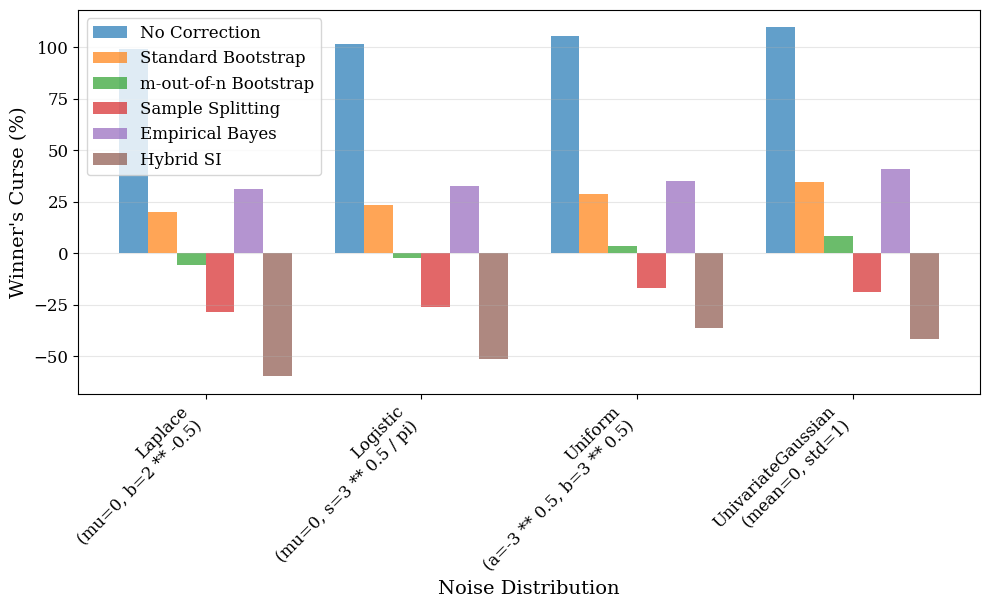

Noise Distribution              Laplace\n(mu=0, b=2 ** -0.5)  \
Estimator            Statistic                                 
No Correction        mean                          99.179387   
                     std                          173.863378   
Standard Bootstrap   mean                          19.937473   
                     std                          193.526703   
m-out-of-n Bootstrap mean                          -5.516397   
                     std                          194.741163   
Sample Splitting     mean                         -28.684279   
                     std                          280.295053   
Empirical Bayes      mean                          31.229509   
                     std                          163.938457   
Hybrid SI            mean                         -59.616127   
                     std                          305.875496   

Noise Distribution              Logistic\n(mu=0, s=3 ** 0.5 / pi)  \
Estimator            Statistic                                      
No Correction        mean                              101.764967   
                     std                               172.951859   
Standard Bootstrap   mean                               23.338571   
                     std                               192.079609   
m-out-of-n Bootstrap mean                               -2.372733   
                     std                               193.111107   
Sample Splitting     mean                              -26.271625   
                     std                               282.053158   
Empirical Bayes      mean                               32.890793   
                     std                               163.742932   
Hybrid SI            mean                              -51.321308   
                     std                               300.274084   

Noise Distribution              Uniform\n(a=-3 ** 0.5, b=3 ** 0.5)  \
Estimator            Statistic                                       
No Correction        mean                               105.518045   
                     std                                170.440325   
Standard Bootstrap   mean                                28.755596   
                     std                                189.480006   
m-out-of-n Bootstrap mean                                 3.347963   
                     std                                190.024551   
Sample Splitting     mean                               -17.020349   
                     std                                284.362161   
Empirical Bayes      mean                                34.920832   
                     std                                160.223698   
Hybrid SI            mean                               -36.112720   
                     std                                297.019654   

Noise Distribution              UnivariateGaussian\n(mean=0, std=1)  
Estimator            Statistic                                       
No Correction        mean                                109.628445  
                     std                                 170.685436  
Standard Bootstrap   mean                                 34.729636  
                     std                                 191.371736  
m-out-of-n Bootstrap mean                                  8.345278  
                     std                                 192.743467  
Sample Splitting     mean                                -18.747318  
                     std                                 293.510987  
Empirical Bayes      mean                                 40.962604  
                     std                                 162.858211  
Hybrid SI            mean                                -41.686870  
                     std                                 293.642027

In [9]:
plot_noise_dist_wc_comparison(
    results, config
)
compute_noise_dist_sum_stats(
    results, config, stats_list=['mean', 'std']
)

In [11]:
latex_table = generate_noise_dist_sum_stats_latex_table(results, config)
print(latex_table)

\begin{tabular}{ccccc}
\toprule
 & Laplace
(mu=0, b=2 ** -0.5) & Logistic
(mu=0, s=3 ** 0.5 / pi) & Uniform
(a=-3 ** 0.5, b=3 ** 0.5) & UnivariateGaussian
(mean=0, std=1) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}99.18\%\\ (173.86\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}101.76\%\\ (172.95\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}105.52\%\\ (170.44\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}109.63\%\\ (170.69\%)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}19.94\%\\ (193.53\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}23.34\%\\ (192.08\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}28.76\%\\ (189.48\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}34.73\%\\ (191.37\%)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}-5.52\%\\ (194.74\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}-2.37\%\\ (193.11\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}3.35\%\\ (190.02\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}8.35\%\\ (192.74\%)\end{tabular} 

## Number of Treatments

In [9]:
result_dir = '../results/ab_test_n_treatments_20251122_122314'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    n_treatments_results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    n_treatments_config: dict = json.load(f)

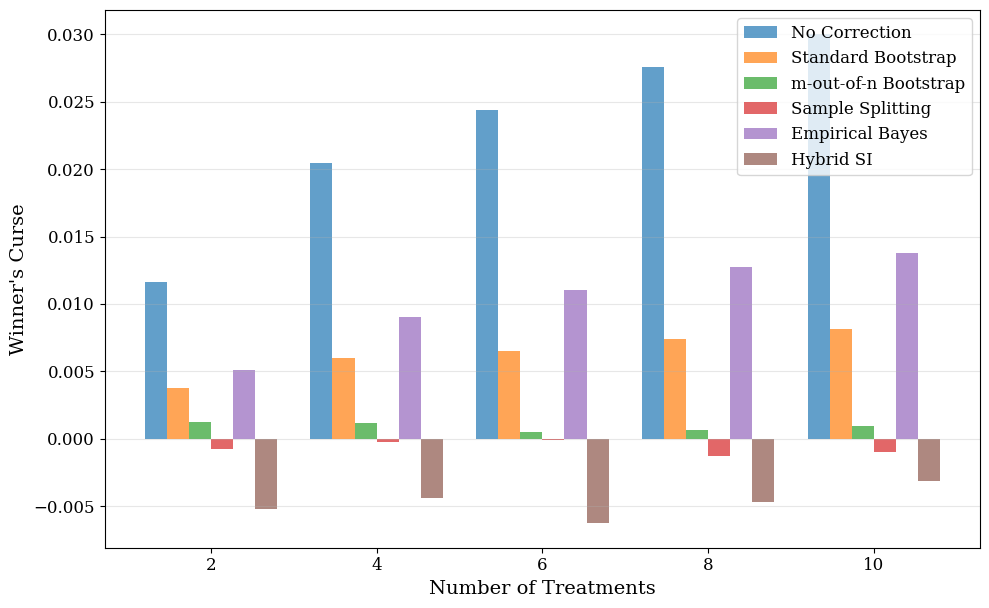

N Treatments                           2         4         6         8  \
Estimator            Statistic                                           
No Correction        mean       0.011610  0.020446  0.024414  0.027602   
                     median     0.010119  0.019789  0.024330  0.026501   
                     std        0.016689  0.014351  0.013194  0.012644   
Standard Bootstrap   mean       0.003797  0.006012  0.006517  0.007368   
                     median     0.002180  0.004434  0.005284  0.005282   
                     std        0.018853  0.017568  0.016730  0.016236   
m-out-of-n Bootstrap mean       0.001233  0.001144  0.000496  0.000658   
                     median    -0.000640 -0.000543 -0.000567 -0.001078   
                     std        0.019013  0.017569  0.016816  0.016374   
Sample Splitting     mean      -0.000777 -0.000210 -0.000087 -0.001312   
                     median    -0.000944  0.000499  0.000155 -0.001746   
                     std        0.028953  0.028619  0.028724  0.029528   
Empirical Bayes      mean       0.005063  0.009037  0.011029  0.012708   
                     median     0.004424  0.008159  0.010578  0.011747   
                     std        0.015567  0.012867  0.011521  0.010927   
Hybrid SI            mean      -0.005222 -0.004370 -0.006275 -0.004707   
                     median    -0.001680 -0.000347 -0.001928 -0.002204   
                     std        0.030680  0.031772  0.033065  0.031937   

N Treatments                          10  
Estimator            Statistic            
No Correction        mean       0.029990  
                     median     0.029106  
                     std        0.011724  
Standard Bootstrap   mean       0.008150  
                     median     0.006331  
                     std        0.015311  
m-out-of-n Bootstrap mean       0.000910  
                     median    -0.001125  
                     std        0.015285  
Sample Splitting     mean      -0.001018  
                     median    -0.001254  
                     std        0.027242  
Empirical Bayes      mean       0.013785  
                     median     0.012787  
                     std        0.009912  
Hybrid SI            mean      -0.003136  
                     median    -0.000541  
                     std        0.031800

In [10]:
plot_n_treatments_wc_comparison(
    n_treatments_results, 
    n_treatments_config, 
    normalize=False
)
compute_n_treatments_sum_stats(
    n_treatments_results,
    n_treatments_config,
    stats_list=['mean', 'median', 'std'],
    normalize=False
)

In [11]:
latex_table = generate_n_treatments_sum_stats_latex_table(
    n_treatments_results,
    n_treatments_config,
    stats='mean',
    normalize=False, 
    decimals=4
)
print(latex_table)

\begin{tabular}{cccccc}
\toprule
 & 2 & 4 & 6 & 8 & 10 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}0.0116\\ (0.0167)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0204\\ (0.0144)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0244\\ (0.0132)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0276\\ (0.0126)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0300\\ (0.0117)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}0.0038\\ (0.0189)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0060\\ (0.0176)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0065\\ (0.0167)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0074\\ (0.0162)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0081\\ (0.0153)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}0.0012\\ (0.0190)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0011\\ (0.0176)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0005\\ (0.0168)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.0007\\ (0.0164)\end{tabular} & \begin{tabular}[c]{@{}c@{}}0.00

# Bernoulli Response

In [14]:
result_dir = '../results/ab_test_bernoulli_20251122_122421'

with open(result_dir + '/results.pkl', 'rb') as f:
    bernoulli_results: dict = pickle.load(f)

with open(result_dir + '/config.json', 'r') as f:
    bernoulli_config: dict = json.load(f)

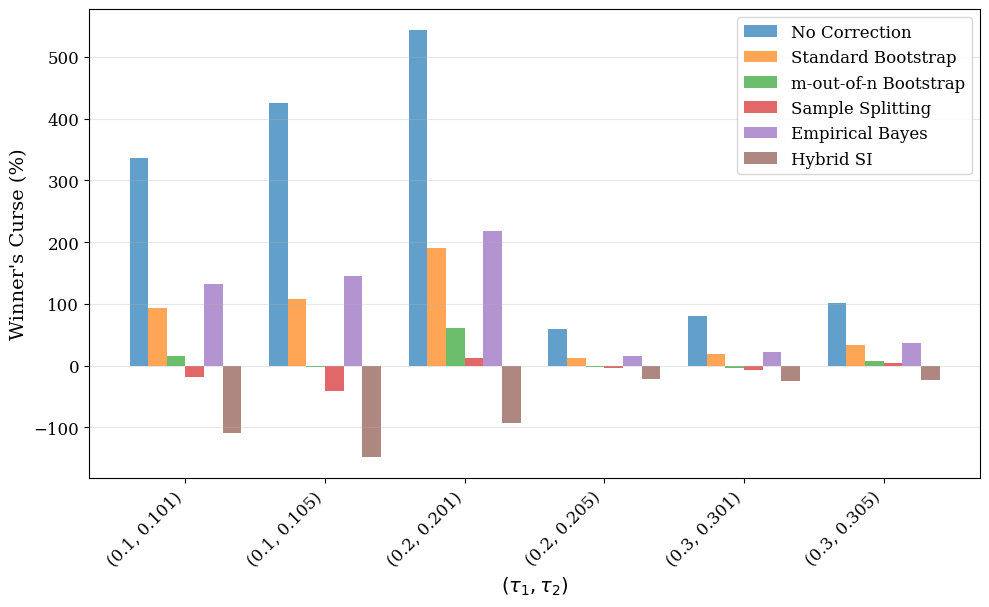

$\Delta\tau$                          0.001                            \
$(\tau_0, \tau_1)$             (0.1, 0.101) (0.2, 0.201) (0.3, 0.301)   
Estimator            Statistic                                          
No Correction        mean        336.880000   425.880000   543.000000   
                     std         502.332027   678.223433   768.725569   
Standard Bootstrap   mean         92.812000   107.850400   191.109600   
                     std         556.143808   744.123024   855.265277   
m-out-of-n Bootstrap mean         15.723224    -2.318395    61.335058   
                     std         556.452482   741.682542   852.224423   
Sample Splitting     mean        -19.280000   -41.640000    11.720000   
                     std         821.123792  1148.043775  1296.539179   
Empirical Bayes      mean        131.867414   144.489355   218.213067   
                     std         462.739538   635.088699   719.345782   
Hybrid SI            mean       -109.991428  -147.902023   -93.777913   
                     std         857.184843  1148.412186  1312.972453   

$\Delta\tau$                          0.005                            
$(\tau_0, \tau_1)$             (0.1, 0.105) (0.2, 0.205) (0.3, 0.305)  
Estimator            Statistic                                         
No Correction        mean         58.800000    79.888000   101.992000  
                     std         107.075002   139.975953   159.793567  
Standard Bootstrap   mean         12.956640    18.632800    33.072320  
                     std         117.760205   152.508205   176.273709  
m-out-of-n Bootstrap mean         -2.647135    -3.607135     7.501013  
                     std         117.821186   153.022949   175.910232  
Sample Splitting     mean         -4.544000    -7.888000     3.816000  
                     std         174.395849   236.038343   262.972299  
Empirical Bayes      mean         15.374346    21.876818    37.170233  
                     std         101.394684   132.974071   151.095637  
Hybrid SI            mean        -21.884017   -24.623410   -23.300761  
                     std         171.574351   226.027119   268.883070

In [15]:
plot_bernoulli_wc_comparison(
    bernoulli_results, 
    bernoulli_config, 
    normalize=True
)
stats_df = compute_bernoulli_sum_stats(
    bernoulli_results,
    bernoulli_config,
    normalize=True,
    stats_list=['mean', 'std'],
)
stats_df

In [16]:
latex_table = generate_bernoulli_sum_stats_latex_table(
    bernoulli_results,
    bernoulli_config,
    normalize=True,
)
print(latex_table)

\begin{tabular}{lcccccc}
\toprule
$\Delta\tau$ & \multicolumn{3}{c}{0.001000} & \multicolumn{3}{c}{0.005000} \\
$(\tau_0, \tau_1)$ & (0.1, 0.101) & (0.2, 0.201) & (0.3, 0.301) & (0.1, 0.105) & (0.2, 0.205) & (0.3, 0.305) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}336.88\%\\ (502.33\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}425.88\%\\ (678.22\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}543.00\%\\ (768.73\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}58.80\%\\ (107.08\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}79.89\%\\ (139.98\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}101.99\%\\ (159.79\%)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}92.81\%\\ (556.14\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}107.85\%\\ (744.12\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}191.11\%\\ (855.27\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}12.96\%\\ (117.76\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}18.63\%\\ (152.51\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}33.

In [17]:
print('50/50 Split Sample Splitting')
for tau_tup, value in bernoulli_results.items():
    delta_tau = tau_tup[1] - tau_tup[0]

    agree_pct_avg = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).mean()
    agree_pct_std = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).std() / value['rank_and_select_nc_selection_arr'].shape[0] ** 0.5
    
    clairvoyant_val = 1 + delta_tau
    focal_val_avg = np.mean(value['rank_and_select_nc_val_true_arr'])
    focal_val_std = np.std(value['rank_and_select_nc_val_true_arr'])
    ss_val_avg = np.mean(value['rank_and_select_sample_splitting_val_true_arr'])
    ss_val_std = np.std(value['rank_and_select_sample_splitting_val_true_arr'])
    random_val = 1 + delta_tau / 2

    val_diff = focal_val_avg - ss_val_avg
    val_diff_std = (focal_val_std ** 2 + ss_val_std ** 2) ** 0.5

    print(f"(tau1, tau2) = {tau_tup}:")
    print(f"  Pct. of Same Decision: {agree_pct_avg:.2%} ({agree_pct_std:.2%})")
    print(f"  Clairvoyant Policy Value: {clairvoyant_val:.6f}")
    print(f"  Focal Policy Value: {focal_val_avg:.6f} ({focal_val_std:.6f})")
    print(f"  Sample Splitting Value: {ss_val_avg:.6f} ({ss_val_std:.6f})")
    print(f"  Random Guessing Value: {random_val:.6f}")
    print(f"  Val Diff: {val_diff:.6f} ({val_diff_std:.6f})")
    print(f"  Val Diff / Delta Tau: {val_diff / delta_tau:.4%} ({val_diff_std / delta_tau:.4%})")

50/50 Split Sample Splitting
(tau1, tau2) = (0.1, 0.101):
  Pct. of Same Decision: 76.80% (1.89%)
  Clairvoyant Policy Value: 1.001000
  Focal Policy Value: 0.100508 (0.000500)
  Sample Splitting Value: 0.100516 (0.000500)
  Random Guessing Value: 1.000500
  Val Diff: -0.000008 (0.000707)
  Val Diff / Delta Tau: -0.8000% (70.6880%)
(tau1, tau2) = (0.2, 0.201):
  Pct. of Same Decision: 76.00% (1.91%)
  Clairvoyant Policy Value: 1.001000
  Focal Policy Value: 0.200514 (0.000500)
  Sample Splitting Value: 0.200506 (0.000500)
  Random Guessing Value: 1.000500
  Val Diff: 0.000008 (0.000707)
  Val Diff / Delta Tau: 0.8000% (70.6943%)
(tau1, tau2) = (0.3, 0.301):
  Pct. of Same Decision: 76.20% (1.90%)
  Clairvoyant Policy Value: 1.001000
  Focal Policy Value: 0.300510 (0.000500)
  Sample Splitting Value: 0.300516 (0.000500)
  Random Guessing Value: 1.000500
  Val Diff: -0.000006 (0.000707)
  Val Diff / Delta Tau: -0.6000% (70.6855%)
(tau1, tau2) = (0.1, 0.105):
  Pct. of Same Decision: 79.4

# Logit Response

In [49]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'logit', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

logit_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

In [50]:
logit_te_result_dict = {logit_te: None for logit_te in logit_te_list}

for te_tuple in logit_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]),PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   31.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   24.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   31.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.25)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.3, 0.35)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.3s finished


In [51]:
with open('results/ab_test_logit_delta_tau.pkl', 'wb') as f:
    pickle.dump(logit_te_result_dict, f)

with open('results/ab_test_logit_delta_tau.pkl', 'rb') as f:
    logit_te_result_dict = pickle.load(f)

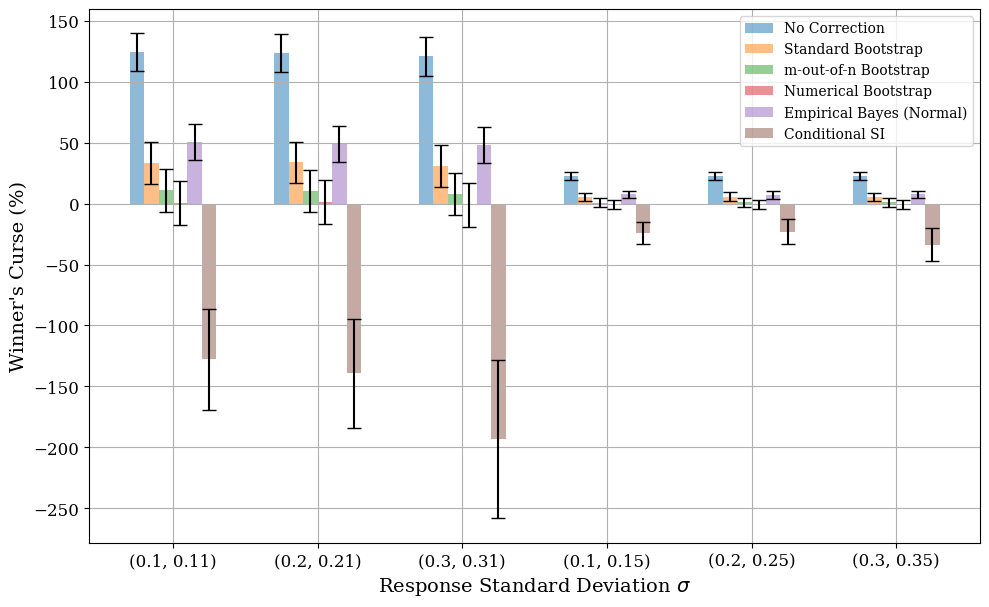

$\Delta\tau = 0.01$  \
                                $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction            Mean                             124.24   
                         Median                           110.21   
                         S.E.                               7.99   
Standard Bootstrap       Mean                              33.26   
                         Median                            24.32   
                         S.E.                               8.80   
m-out-of-n Bootstrap     Mean                              10.89   
                         Median                             2.45   
                         S.E.                               8.90   
Numerical Bootstrap      Mean                               0.26   
                         Median                            -9.02   
                         S.E.                               9.17   
Empirical Bayes (Normal) Mean                              50.60   
                         Median                            40.90   
                         S.E.                               7.55   
Conditional SI           Mean                            -127.89   
                         Median                           -11.51   
                         S.E.                              21.11   

                                                                  \
                                $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction            Mean                             123.49   
                         Median                           116.92   
                         S.E.                               7.89   
Standard Bootstrap       Mean                              33.88   
                         Median                            21.31   
                         S.E.                               8.69   
m-out-of-n Bootstrap     Mean                              10.74   
                         Median                            -6.09   
                         S.E.                               8.78   
Numerical Bootstrap      Mean                               1.32   
                         Median                           -15.48   
                         S.E.                               9.05   
Empirical Bayes (Normal) Mean                              49.15   
                         Median                            38.47   
                         S.E.                               7.44   
Conditional SI           Mean                            -139.40   
                         Median                           -10.88   
                         S.E.                              22.67   

                                                                  \
                                $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction            Mean                             120.84   
                         Median                           115.57   
                         S.E.                               8.04   
Standard Bootstrap       Mean                              30.98   
                         Median                            23.33   
                         S.E.                               8.88   
m-out-of-n Bootstrap     Mean                               8.01   
                         Median                             0.92   
                         S.E.                               8.96   
Numerical Bootstrap      Mean                              -1.43   
                         Median                           -14.36   
                         S.E.                               9.23   
Empirical Bayes (Normal) Mean                              48.14   
                         Median                            45.44   
                         S.E.                               7.58   
Conditional SI           Mean                            -193.60   
                         Median                           -18.43   
                         S.E.  

In [52]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(logit_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in logit_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in logit_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(logit_te_list)), labels=logit_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [53]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.01$', '$\Delta\\tau = 0.05$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.01$} & \multicolumn{3}{r}{$\Delta\tau = 0.05$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) & $(\tau_1, \tau_2)$ = (0.1, 0.15) & $(\tau_1, \tau_2)$ = (0.2, 0.25) & $(\tau_1, \tau_2)$ = (0.3, 0.35) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$124.24\%^{***}$\\ ($7.99$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$123.49\%^{***}$\\ ($7.89$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$120.84\%^{***}$\\ ($8.04$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.89\%^{***}$\\ ($1.65$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.94\%^{***}$\\ ($1.64$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.69\%^{***}$\\ ($1.65$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$33.26\%^{***}$\\ ($8.80$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$33.88\%^{***}$\\ ($8.69$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$30.98\%^{***}$\\ (

## Sample Size

In [54]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
    'response_type': 'logit',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [50, 100, 500, 1000, 2500, 5000]

In [55]:
logit_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   28.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   36.0s finished
c:\Users\xusik\Desktop\research\winners-curse\core\rct.py:482: RuntimeWarning: Mean of empty slice
  f'{optimizer}_{estimator}_val_est_avg': np.nanmean(temp_val_est_arr),
c:\Users\xusik\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\xusik\Desktop\research\winners-curse\core\rct.py:484: RuntimeWarning: Mean of empty slice
  f'{optimizer}_{estimator}_wc_avg': np.nanmean(temp_wc_arr),
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   40.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   51.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.2min finished


In [56]:
with open('results/ab_test_logit_sample_size.pkl', 'wb') as f:
    pickle.dump(logit_sample_size_result_dict, f)

with open('results/ab_test_logit_sample_size.pkl', 'rb') as f:
    logit_sample_size_result_dict = pickle.load(f)

c:\Users\xusik\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


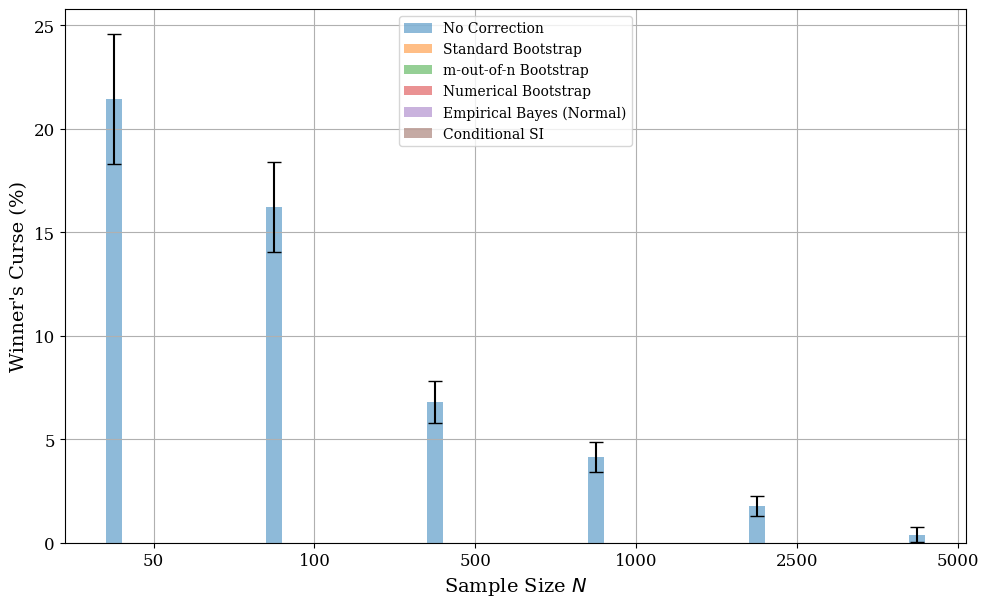

$N=50$  $N=100$  $N=500$  $N=1000$  $N=2500$  \
No Correction            Mean     21.43    16.21     6.79      4.16      1.76   
                         Median   18.78    14.09     5.63      3.76      1.88   
                         S.E.      1.60     1.11     0.52      0.37      0.25   
Standard Bootstrap       Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
m-out-of-n Bootstrap     Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
Numerical Bootstrap      Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
Empirical Bayes (Normal) Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
Conditional SI           Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   

                                 $N=5000$  
No Correction            Mean        0.38  
                         Median      0.19  
                         S.E.        0.19  
Standard Bootstrap       Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
m-out-of-n Bootstrap     Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
Numerical Bootstrap      Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
Empirical Bayes (Normal) Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
Conditional SI           Mean         NaN  
                         Median       NaN  
                         S.E.         NaN

In [57]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [58]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$21.43\%^{***}$\\ ($1.60\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$16.21\%^{***}$\\ ($1.11\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.79\%^{***}$\\ ($0.52\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.16\%^{***}$\\ ($0.37\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.76\%^{***}$\\ ($0.25\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.38\%^{**}$\\ ($0.19\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\

c:\Users\xusik\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\xusik\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# Sample Size

## Signal-to-Noise Ratio

In [6]:
# continuous specification
cont_dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), None],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'continuous', 
    'dgp_seed': 0
}

optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 5000}

estimators_dict = {}

delta_tau_list = [0.005, 0.01, 0.02]
sample_size_list = [2500, 5000, 10000, 50000, 100000, 250000, 500000]

In [7]:
ber_sample_size_result_dict = {}
cont_sample_size_result_dict = {}

for delta_tau in delta_tau_list:
    for sample_size in sample_size_list:
        print(f'\nDelta Tau = {delta_tau}, Sample Size = {sample_size}')
        data_params['sample_size'] = sample_size
        cont_dgp_params['base_effects'][1] = PointMass(1 + delta_tau)

        cont_result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=cont_dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )
        cont_sample_size_result_dict[(delta_tau, sample_size)] = rct.calculate_winners_curse_measures(
            result_records=cont_result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params,
        )


Delta Tau = 0.005, Sample Size = 2500
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 3382 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    3.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Delta Tau = 0.005, Sample Size = 5000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 4150 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s


...

[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s



Delta Tau = 0.02, Sample Size = 250000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 1900 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 4981 out of 5000 | elapsed:    7.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    7.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Delta Tau = 0.02, Sample Size = 500000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1100 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 3100 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   15.0s finished


In [8]:
optimizer_key = 'rank_and_select'

cont_result_records = [
    {
        'delta_tau': delta_tau, 
        'sample_size': sample_size, 
        'p_val': ttest_1samp(result_dict[f'{optimizer_key}_nc_wc_arr'], 0)[1],
        'wc_avg': result_dict[f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100,
        'wc_se': result_dict[f'{optimizer_key}_nc_wc_arr'].std() / result_dict[f'{optimizer_key}_nc_wc_arr'].shape[0] ** 0.5 / delta_tau * 100,
    }
    for (delta_tau, sample_size), result_dict in cont_sample_size_result_dict.items()
]

wc_df = pd.DataFrame(cont_result_records)
def aggregate_result(avg, se, p_val) -> float:
    sig_level = significance_level_with_p_val(p_val)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    return "\\begin{tabular}[c]{@{}c@{}}" + f"${avg:.2f}\%" + sig_level + f"$\\\\ (${se:.2f}\%$)" + "\end{tabular}"
wc_df['wc'] = wc_df.apply(lambda x: aggregate_result(x['wc_avg'], x['wc_se'], x['p_val']), axis=1)
wc_df = wc_df.pivot(index='sample_size', columns='delta_tau', values='wc')

# delete names for the index column 
wc_df.index.name = None
wc_df.columns.name = None

wc_df.columns = [
    f'$\\Delta\\tau / \\sigma$ = {delta_tau/1 * 100:.1f}\%' for delta_tau in wc_df.columns
]
wc_df.index = [
    f'$N = {sample_size}$' for sample_size in wc_df.index
]

print(wc_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))


\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma$ = 0.5\% & $\Delta\tau / \sigma$ = 1.0\% & $\Delta\tau / \sigma$ = 2.0\% \\
\midrule
$N = 2500$ & \begin{tabular}[c]{@{}c@{}}$231.67\%^{***}$\\ ($4.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$110.79\%^{***}$\\ ($2.43\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$46.19\%^{***}$\\ ($1.28\%$)\end{tabular} \\
$N = 5000$ & \begin{tabular}[c]{@{}c@{}}$157.97\%^{***}$\\ ($3.33\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$72.65\%^{***}$\\ ($1.72\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$24.28\%^{***}$\\ ($0.95\%$)\end{tabular} \\
$N = 10000$ & \begin{tabular}[c]{@{}c@{}}$106.71\%^{***}$\\ ($2.42\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$44.38\%^{***}$\\ ($1.29\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$10.21\%^{***}$\\ ($0.70\%$)\end{tabular} \\
$N = 50000$ & \begin{tabular}[c]{@{}c@{}}$36.66\%^{***}$\\ ($1.14\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.17\%^{***}$\\ ($0.62\%$)\end{tabular} & \begin{tabular}[c]{

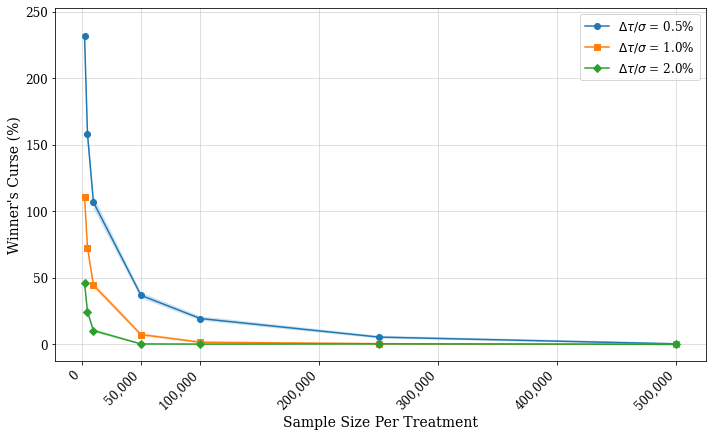

In [17]:
wc_avg_df = pd.DataFrame.from_records(cont_result_records).pivot(index='sample_size', columns='delta_tau', values='wc_avg')
wc_se_df = pd.DataFrame.from_records(cont_result_records).pivot(index='sample_size', columns='delta_tau', values='wc_se')

fig, ax = plt.subplots(figsize=(10, 6.18))

markers = ['o', 's', 'D', 'v', '^', 'P', 'X']

for idx, delta_tau in enumerate(wc_avg_df.columns):
    ax.plot(
        wc_avg_df.index, 
        wc_avg_df[delta_tau], f'{markers[idx]}-', 
        label=f'$\\Delta\\tau / \\sigma$ = {delta_tau/1 * 100:.1f}%'
    )
    ax.fill_between(
        wc_avg_df.index, 
        wc_avg_df[delta_tau] - 1.96 * wc_se_df[delta_tau], 
        wc_avg_df[delta_tau] + 1.96 * wc_se_df[delta_tau], alpha=0.2
    )

# add comma to the x-axis
x_tick_labels = [0, 50000, 100000, 200000, 300000, 400000, 500000]
ax.set_xticks(x_tick_labels, labels=[f'{item:,}' for item in x_tick_labels], rotation=45, ha='right')
ax.legend(fontsize=legend_label_size)
ax.set_xlabel('Sample Size Per Treatment', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('figures/rct_delta_tau_sample_size.jpg')
plt.show()

## Number of Treatments

In [ ]:
# continuous specification
cont_dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# # logit specification
# log_dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
#     'response_type': 'logit', 
#     'dgp_seed': 0
# }

optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {}

delta_tau = 0.0 
n_treatments_list = [2, 4, 6, 8, 10]
sample_size_list = [2500, 5000, 10000, 25000, 50000, 100000, 250000, 500000]
# sample_size_list = [500, 2500, 10000, 25000, 50000]

In [11]:
cont_sample_size_result_dict = {}

for n_treatments in n_treatments_list:
    for sample_size in sample_size_list:
        print(f'\nNumber of Treatments = {n_treatments}, Sample Size = {sample_size}')
        data_params['sample_size'] = sample_size
        cont_dgp_params['base_effects'] = [PointMass(1 + delta_tau * i) for i in range(n_treatments)]
        cont_dgp_params['noise_vars'] = [UnivariateGaussian(0, std=1) for i in range(n_treatments)]

        cont_result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=cont_dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )
        cont_sample_size_result_dict[(n_treatments, sample_size)] = rct.calculate_winners_curse_measures(
            result_records=cont_result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params,
        )


Number of Treatments = 2, Sample Size = 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Number of Treatments = 2, Sample Size = 2500
Running 500 experiments...

Number of Treatments = 2, Sample Size = 10000
Running 500 experiments...

Number of Treatments = 2, Sample Size = 25000
Running 500 experiments...

Number of Treatments = 2, Sample Size = 50000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 4, Sample Size = 500
Running 500 experiments...

Number of Treatments = 4, Sample Size = 2500
Running 500 experiments...

Number of Treatments = 4, Sample Size = 10000
Running 500 experiments...

Number of Treatments = 4, Sample Size = 25000
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Number of Treatments = 10, Sample Size = 25000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s



Number of Treatments = 10, Sample Size = 50000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.7s finished


In [69]:
# with open('results/ab_test_n_treatments_sample_size.pkl', 'wb') as f:
#     pickle.dump(cont_sample_size_result_dict, f)

with open('results/ab_test_n_treatments_sample_size.pkl', 'rb') as f:
    cont_sample_size_result_dict = pickle.load(f)

In [63]:
optimizer_key = 'rank_and_select'

cont_result_records = [
    {
        'n_treatments': n_treatments, 
        'sample_size': sample_size, 
        'p_val': ttest_1samp(result_dict[f'{optimizer_key}_nc_wc_arr'], 0)[1],
        'wc_avg': result_dict[f'{optimizer_key}_nc_wc_avg'],
        'wc_se': result_dict[f'{optimizer_key}_nc_wc_se'],
    }
    for (n_treatments, sample_size), result_dict in cont_sample_size_result_dict.items()
]

wc_df = pd.DataFrame(cont_result_records)
def aggregate_result(avg, se, p_val) -> float:
    sig_level = significance_level_with_p_val(p_val)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    return "\\begin{tabular}[c]{@{}c@{}}" + f"${avg:.4f}" + sig_level + f"$\\\\ (${se:.4f}$)" + "\end{tabular}"
wc_df['wc'] = wc_df.apply(lambda x: aggregate_result(x['wc_avg'], x['wc_se'], x['p_val']), axis=1)
wc_df = wc_df.pivot(index='sample_size', columns='n_treatments', values='wc')

# delete names for the index column 
wc_df.index.name = None
wc_df.columns.name = None

wc_df.columns = [
    f'Number of Treatments = {n_treatments}' for n_treatments in wc_df.columns
]
wc_df.index = [
    f'$N = {sample_size}$' for sample_size in wc_df.index
]

print(wc_df.style.to_latex(
    column_format='c' * (len(n_treatments_list) + 1), 
    hrules=True
))


\begin{tabular}{cccccc}
\toprule
 & Number of Treatments = 2 & Number of Treatments = 4 & Number of Treatments = 6 & Number of Treatments = 8 & Number of Treatments = 10 \\
\midrule
$N = 10000$ & \begin{tabular}[c]{@{}c@{}}$0.0054^{***}$\\ ($0.0004$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0098^{***}$\\ ($0.0003$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0126^{***}$\\ ($0.0003$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0140^{***}$\\ ($0.0003$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0152^{***}$\\ ($0.0003$)\end{tabular} \\
$N = 25000$ & \begin{tabular}[c]{@{}c@{}}$0.0036^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0065^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0082^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0091^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0097^{***}$\\ ($0.0002$)\end{tabular} \\
$N = 50000$ & \begin{tabular}[c]{@{}c@{}}$0.0025^{***}$\\ ($0.0002$)\end{tabular} & \beg

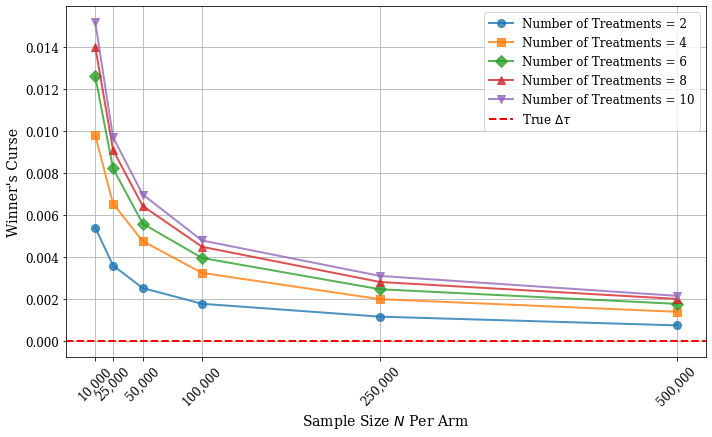

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

markers_list = ['o', 's', 'D', '^', 'v', 'x']

# plot the winner's curse as a function of the sample size for each number of treatments
for idx, n_treatments in enumerate(n_treatments_list):
    bar_values = [result_dict['wc_avg'] for result_dict in cont_result_records if result_dict['n_treatments'] == n_treatments]
    bar_errors = [result_dict['wc_se'] for result_dict in cont_result_records if result_dict['n_treatments'] == n_treatments]

    ax.plot(
        sample_size_list, bar_values, label=f'Number of Treatments = {n_treatments}', 
        alpha=0.8, linewidth=2, 
        marker=markers_list[idx], markersize=8
    )


ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label=r'True $\Delta\tau$')

ax.set_xlabel(r'Sample Size $N$ Per Arm', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse', fontsize=axis_label_size)
x_ticks = sample_size_list
ax.set_xticks(
    x_ticks, labels=[f'{x:,}' for x in x_ticks], rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.savefig('figures/rct_n_treatments_sample_size.jpg')
plt.show()

## Imbalanced Sample Sizes

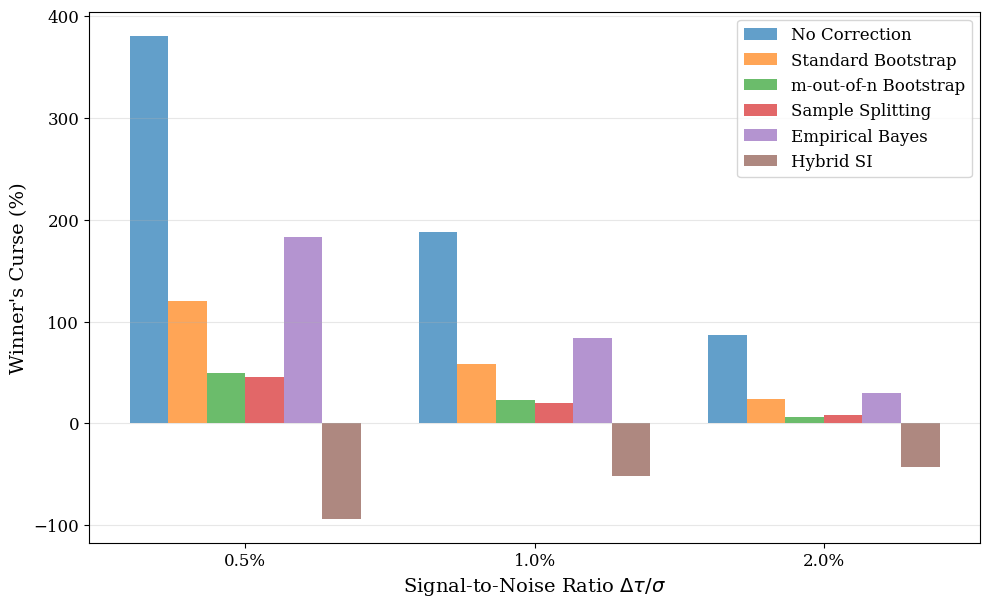

\begin{tabular}{cccc}
\toprule
$\Delta\tau/\sigma$ & 0.5% & 1.0% & 2.0% \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}380.39\%\\ (557.74\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}187.59\%\\ (280.93\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}86.98\%\\ (146.20\%)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}120.48\%\\ (625.64\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}58.38\%\\ (318.90\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}24.05\%\\ (168.52\%)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}49.22\%\\ (630.77\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}22.78\%\\ (321.73\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}6.43\%\\ (170.39\%)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}45.07\%\\ (912.71\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}19.84\%\\ (463.30\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}8.22\%\\ (241.91\%)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}182.71\%\\ (460.90\%)\end{tabul

$\Delta\tau/\sigma$                    0.5%        1.0%        2.0%
Estimator            Statistic                                     
No Correction        mean        380.390153  187.587493   86.979834
                     median      235.786845  116.818804   54.002355
                     std         557.742006  280.934752  146.202280
Standard Bootstrap   mean        120.476986   58.375554   24.053721
                     median      -41.830016  -23.698502  -15.953207
                     std         625.643015  318.902063  168.521723
m-out-of-n Bootstrap mean         49.220623   22.778814    6.426319
                     median     -119.809225  -61.288033  -37.547401
                     std         630.772316  321.732524  170.390591
Sample Splitting     mean         45.067587   19.839462    8.223483
                     median       56.282246   28.698438    8.690768
                     std         912.706209  463.301621  241.908156
Empirical Bayes      mean        182.705622   83.741962   29.497504
                     median      103.327793   42.146110    7.468902
                     std         460.900999  232.071747  122.433078
Hybrid SI            mean        -93.482485  -52.103475  -42.655937
                     median       16.736289   10.715033    4.338048
                     std        1008.451387  520.073612  291.639041

In [59]:
result_dir = '../results/ab_test_imbalanced_20251130_220144//'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    config: dict = json.load(f)

plot_snr_wc_comparison(results, config)
stats_df = compute_snr_sum_stats(
    results, config, ['mean', 'median', 'std']
)

print(generate_snr_sum_stats_latex_table(results, config, normalize=True))

stats_df

In [41]:
result_dir = '../results/ab_test_imbalanced_snr_20251130_212756//'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    config: dict = json.load(f)

In [56]:
# Convert taus to tuples for consistent key matching
tau_tuples = [tuple(tau) for tau in config['comparative_statics']['tau_list']]
sample_size_tuples = [tuple(ss) for ss in config['comparative_statics']['sample_size_list']]

# Extract winner's curse values for each combination
wc_avg_matrix = np.zeros((len(tau_tuples), len(sample_size_tuples)))
wc_std_matrix = np.zeros((len(tau_tuples), len(sample_size_tuples)))

for i, tau in enumerate(tau_tuples):
    for j, sample_size in enumerate(sample_size_tuples):
        wc_avg_matrix[i, j] = np.mean(results[(sample_size, tau)]['nc_wc_arr']) / (tau[1] - tau[0]) * 100
        wc_std_matrix[i, j] = np.std(results[(sample_size, tau)]['nc_wc_arr']) / (tau[1] - tau[0]) * 100

df = pd.DataFrame(data=wc_avg_matrix, index=['{:.2%}'.format((tau[1] - tau[0]) / 1) for tau in tau_tuples], columns=sample_size_tuples).T
df.columns.name = r'$\Delta\tau / \sigma$'
df.index.name = r'$(N_1, N_2)$'

# Generate LaTeX table in the same style as SNR table in analysis.py
# Build LaTeX cells with mean and std in the same format
decimals = 2
normalize = True  # values are already normalized as percentages

latex_data = {}
# Iterate over columns (tau percentages) and rows (sample sizes)
for j, col in enumerate(df.columns):
    col_data = {}
    # Find the tau index for this column
    tau_idx = None
    for i, tau in enumerate(tau_tuples):
        if '{:.2%}'.format((tau[1] - tau[0]) / 1) == col:
            tau_idx = i
            break
    
    for i, idx in enumerate(df.index):
        val = wc_avg_matrix[tau_idx, i]  # Use matrix directly
        std = wc_std_matrix[tau_idx, i]
        # Format cell with mean and std: \begin{tabular}[c]{@{}c@{}}val\%\\ (std\%)\end{tabular}
        cell_str = f"\\begin{{tabular}}[c]{{@{{}}c@{{}}}}{val:.{decimals}f}\\%\\\\ ({std:.{decimals}f}\\%)\\end{{tabular}}"
        col_data[idx] = cell_str
    latex_data[col] = col_data

latex_df = pd.DataFrame(latex_data)
latex_df.columns.name = df.columns.name
latex_df.index.name = df.index.name

latex_table = latex_df.style.to_latex(
    column_format='c' * (len(latex_df.columns) + 1),
    hrules=True
)
print(latex_table)

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma$ & 0.50% & 1.00% & 2.00% \\
\midrule
500 & 4500 & \begin{tabular}[c]{@{}c@{}}364.37\%\\ (517.29\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}179.43\%\\ (260.40\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}81.80\%\\ (132.44\%)\end{tabular} \\
1000 & 4000 & \begin{tabular}[c]{@{}c@{}}289.53\%\\ (405.31\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}140.37\%\\ (204.46\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}63.79\%\\ (105.95\%)\end{tabular} \\
1500 & 3500 & \begin{tabular}[c]{@{}c@{}}272.91\%\\ (366.10\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}132.56\%\\ (185.95\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}58.87\%\\ (96.98\%)\end{tabular} \\
2000 & 3000 & \begin{tabular}[c]{@{}c@{}}241.68\%\\ (346.14\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}116.86\%\\ (174.89\%)\end{tabular} & \begin{tabular}[c]{@{}c@{}}49.50\%\\ (90.87\%)\end{tabular} \\
2500 & 2500 & \begin{tabular}[c]{@{}c@{}}229.32\%\\ (335.47\%)\end{tabular} & \begin{ta

# Sketch

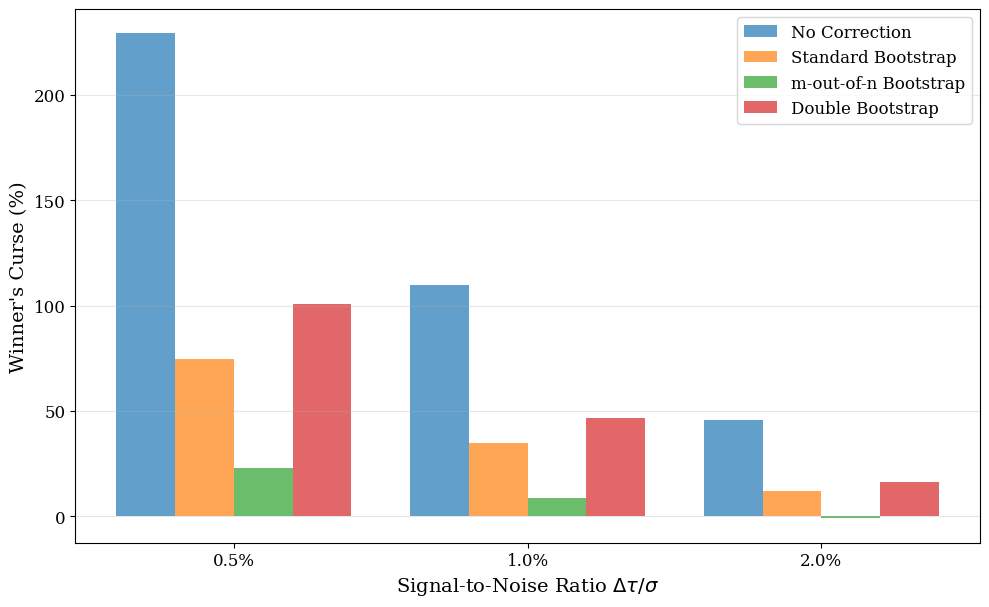

$\Delta\tau/\sigma$                   0.5%        1.0%        2.0%
Estimator            Statistic                                    
No Correction        mean       229.320305  109.628445   45.715523
                     median     202.374180  100.444413   41.030837
                     std        335.472955  170.685436   90.174491
Standard Bootstrap   mean        74.620978   34.729636   11.897672
                     median      39.430336   19.601187    4.154170
                     std        378.505443  191.371736   99.704493
m-out-of-n Bootstrap mean        22.736035    8.345278   -1.139868
                     median     -24.078523  -11.171225   -8.362703
                     std        380.685077  192.743467  100.702759
Double Bootstrap     mean       100.927705   46.383413   15.948718
                     median      64.385497   32.683607   11.242889
                     std        355.639224  180.558838   95.031498

In [8]:
result_dir = '../results/ab_test_double_bootstrap_20251125_220605'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    snr_results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    snr_config: dict = json.load(f)

plot_snr_wc_comparison(snr_results, snr_config)
stats_df = compute_snr_sum_stats(
    snr_results, snr_config, ['mean', 'median', 'std']
)
stats_df

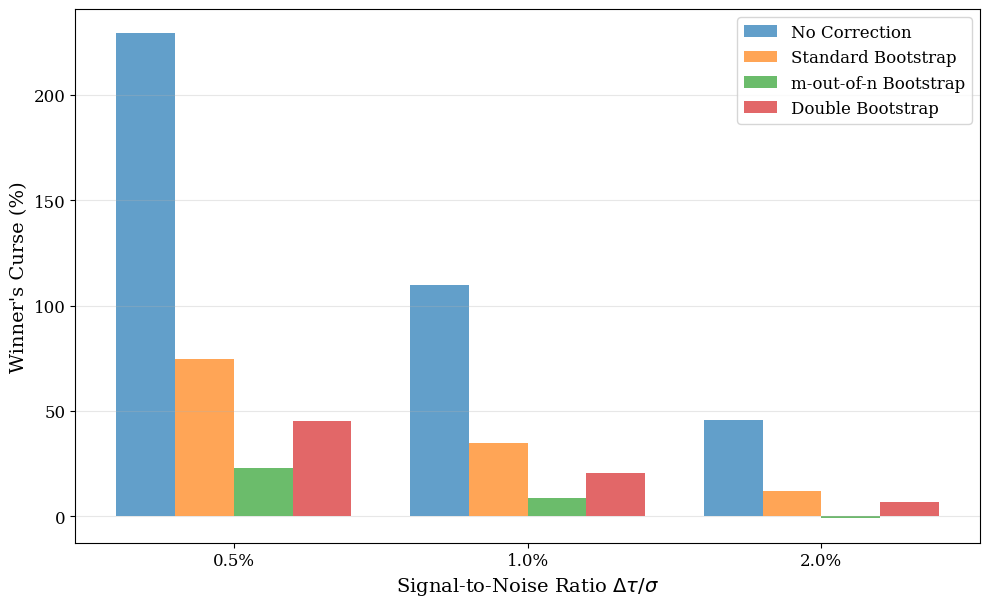

$\Delta\tau/\sigma$                   0.5%        1.0%        2.0%
Estimator            Statistic                                    
No Correction        mean       229.320305  109.628445   45.715523
                     median     202.374180  100.444413   41.030837
                     std        335.472955  170.685436   90.174491
Standard Bootstrap   mean        74.620978   34.729636   11.897672
                     median      39.430336   19.601187    4.154170
                     std        378.505443  191.371736   99.704493
m-out-of-n Bootstrap mean        22.736035    8.345278   -1.139868
                     median     -24.078523  -11.171225   -8.362703
                     std        380.685077  192.743467  100.702759
Double Bootstrap     mean        45.005333   20.484226    6.674149
                     median      -1.904499   -0.276630   -2.707033
                     std        400.061909  201.945575  104.270930

In [9]:
result_dir = '../results/ab_test_double_bootstrap_20251125_235255'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    snr_results: dict = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    snr_config: dict = json.load(f)

plot_snr_wc_comparison(snr_results, snr_config)
stats_df = compute_snr_sum_stats(
    snr_results, snr_config, ['mean', 'median', 'std']
)
stats_df